In [20]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [22]:
df = pd.read_csv("placement_dataset.csv")

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset Shape: (200, 7)


,CGPA,IQ,Aptitude_Score,Communication_Skill,Internships,Branch,Placed
0,8.00,81.0,89.0,1,1,MECH,No
1,7.36,105.0,74.0,5,3,CIVIL,Yes
2,8.15,96.0,62.0,6,1,IT,No
3,9.02,119.0,56.0,6,2,CSE,No
4,NaN,NaN,NaN,3,3,CSE,Yes


In [23]:
print("Dataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CGPA                 190 non-null    float64
 1   IQ                   190 non-null    float64
 2   Aptitude_Score       190 non-null    float64
 3   Communication_Skill  200 non-null    int64  
 4   Internships          200 non-null    int64  
 5   Branch               200 non-null    object 
 6   Placed               200 non-null    object 
dtypes: float64(3), int64(2), object(2)
memory usage: 11.1+ KB

Missing Values:
CGPA                   10
IQ                     10
Aptitude_Score         10
Communication_Skill     0
Internships             0
Branch                  0
Placed                  0
dtype: int64

Duplicate Rows:
0


In [24]:
display(df.describe())

,CGPA,IQ,Aptitude_Score,Communication_Skill,Internships
count,190.000000,190.000000,190.000000,200.000000,200.000000
mean,7.461579,111.357895,70.605263,4.795000,1.480000
std,0.944684,17.670359,16.866013,2.630126,1.093425
min,4.880000,80.000000,40.000000,1.000000,0.000000
25%,6.782500,96.500000,56.250000,2.000000,1.000000
50%,7.510000,111.500000,71.500000,5.000000,1.000000
75%,8.007500,127.000000,84.750000,7.000000,2.000000
max,10.220000,139.000000,99.000000,9.000000,3.000000


Placement Distribution:
Placed
Yes    117
No      83
Name: count, dtype: int64


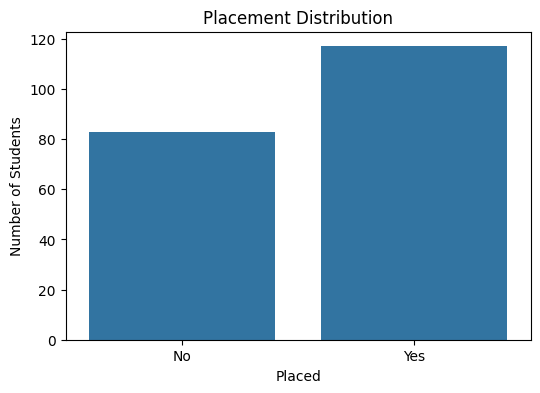

In [25]:
print("Placement Distribution:")
print(df["Placed"].value_counts())

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Placed")

plt.title("Placement Distribution")
plt.xlabel("Placed")
plt.ylabel("Number of Students")

plt.show()

In [26]:
X = df.drop("Placed", axis=1)
y = df["Placed"]

print("Input Features:")
print(X.columns.tolist())

print("\nTarget:")
print("Placed")

Input Features:
['CGPA', 'IQ', 'Aptitude_Score', 'Communication_Skill', 'Internships', 'Branch']

Target:
Placed


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 160
Testing samples: 40


In [28]:
numerical_features = [
    "CGPA",
    "IQ",
    "Aptitude_Score",
    "Communication_Skill",
    "Internships"
]

categorical_features = [
    "Branch"
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numerical_features),
    ("categorical", categorical_pipeline, categorical_features)
])

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", model)
])

print("Model created successfully!")

Model created successfully!


In [29]:
print("Training model...")

pipeline.fit(X_train, y_train)

print("Model training completed! ✅")

Training model...
Model training completed! ✅


In [30]:
y_pred = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("================================")
print("       MODEL ACCURACY")
print("================================")

print("Accuracy:", round(accuracy * 100, 2), "%")

       MODEL ACCURACY
Accuracy: 60.0 %


In [31]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

          No       0.56      0.29      0.38        17
         Yes       0.61      0.83      0.70        23

    accuracy                           0.60        40
   macro avg       0.58      0.56      0.54        40
weighted avg       0.59      0.60      0.57        40



Confusion Matrix:
[[ 5 12]
 [ 4 19]]


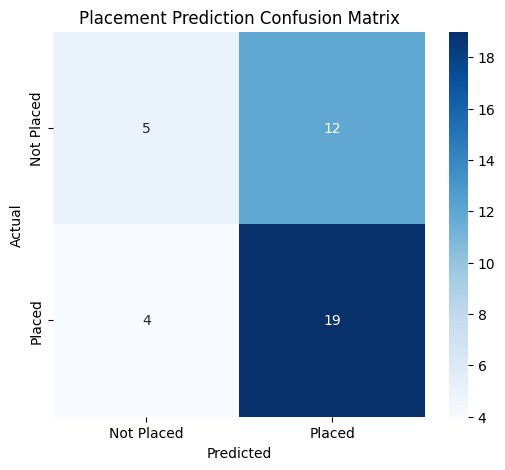

In [32]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Placed", "Placed"],
    yticklabels=["Not Placed", "Placed"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Placement Prediction Confusion Matrix")

plt.show()

In [33]:
new_student = pd.DataFrame({
    "CGPA": [8.5],
    "IQ": [110],
    "Aptitude_Score": [85],
    "Communication_Skill": [4],
    "Internships": [2],
    "Branch": ["CSE"]
})

display(new_student)

,CGPA,IQ,Aptitude_Score,Communication_Skill,Internships,Branch
0,8.5,110,85,4,2,CSE


In [35]:
prediction = pipeline.predict(new_student)
probability = pipeline.predict_proba(new_student)

print("======================================")
print("       PLACEMENT PREDICTION")
print("======================================")

print("Prediction:", prediction[0])

print(
    "Placement Probability:",
    round(probability[0][1] * 100, 2),
    "%"
)

       PLACEMENT PREDICTION
Prediction: Yes
Placement Probability: 71.0 %
